# Satria Data Selection: Vehicle Plate Recognition by Fine-Tuning Keras-OCR (CRAFT detector + CRNN recognizer)

## Import Library

In [68]:
import numpy as np
import pandas as pd
import os, glob, cv2, imgaug, math
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

import keras_ocr, tensorflow as tf
from sklearn.model_selection import train_test_split

DATA_DIR = "../data"
MODEL_DIR = "../models"

# Fine Tuning Detector Model

In [2]:
def xml_to_array(path):
    tree = ET.parse(path)
    root = tree.getroot()
    lst = []
    for obj in root.findall('object'):
        label = obj.find('name').text.upper()
        x1 = int(obj.find("./bndbox/xmin").text)
        y1 = int(obj.find("./bndbox/ymin").text)
        x2 = int(obj.find("./bndbox/xmax").text)
        y2 = int(obj.find("./bndbox/ymax").text)
        box = np.array([
            [x1, y1],
            [x2, y1],
            [x2, y2],
            [x1, y2]
        ])
        lst.append((box, label))
    return [lst]
xml_to_array(f'{DATA_DIR}/train annotations/DataTrain535.xml')

[[(array([[27,  1],
          [58,  1],
          [58, 62],
          [27, 62]]),
   'B'),
  (array([[116,  15],
          [134,  15],
          [134,  80],
          [116,  80]]),
   '1'),
  (array([[148,  22],
          [164,  22],
          [164,  84],
          [148,  84]]),
   '1'),
  (array([[169,  28],
          [202,  28],
          [202,  93],
          [169,  93]]),
   '2'),
  (array([[204,  35],
          [234,  35],
          [234,  98],
          [204,  98]]),
   '4'),
  (array([[292,  54],
          [325,  54],
          [325, 118],
          [292, 118]]),
   'S'),
  (array([[326,  59],
          [357,  59],
          [357, 125],
          [326, 125]]),
   'Q')]]

In [3]:
images_paths = sorted(glob.glob(f'{DATA_DIR}/train images/*.png'), key=lambda x: int(x.split("\\")[-1].split(".")[0][9:]))
dataset = []
for path in images_paths:
    data = (path, xml_to_array(path.replace('images', 'annotations').replace('.png', '.xml')), 1)
    dataset.append(data)

dataset[0]

('dataset/train images\\DataTrain270.png',
 [[(array([[12, 13],
           [23, 13],
           [23, 33],
           [12, 33]]),
    'B'),
   (array([[43, 12],
           [51, 12],
           [51, 32],
           [43, 32]]),
    '1'),
   (array([[53, 11],
           [64, 11],
           [64, 32],
           [53, 32]]),
    '0'),
   (array([[67, 10],
           [76, 10],
           [76, 31],
           [67, 31]]),
    '4'),
   (array([[78,  9],
           [88,  9],
           [88, 30],
           [78, 30]]),
    '0'),
   (array([[116,   8],
           [127,   8],
           [127,  30],
           [116,  30]]),
    'U'),
   (array([[129,   7],
           [140,   7],
           [140,  30],
           [129,  30]]),
    'N')]],
 1)

In [4]:
train, validation = train_test_split(
    dataset, train_size=0.8, random_state=42
)
augmenter = imgaug.augmenters.Sequential([
    imgaug.augmenters.Affine(
        scale=(1.0, 1.2),
        rotate=(-5, 5)
    ),
    imgaug.augmenters.GaussianBlur(sigma=(0, 0.5)),
    imgaug.augmenters.Multiply((0.8, 1.2), per_channel=0.2)
])
generator_kwargs = {'width': 640, 'height': 640}
training_image_generator = keras_ocr.datasets.get_detector_image_generator(
    labels=train,
    augmenter=augmenter,
    **generator_kwargs
)
validation_image_generator = keras_ocr.datasets.get_detector_image_generator(
    labels=validation,
    **generator_kwargs
)

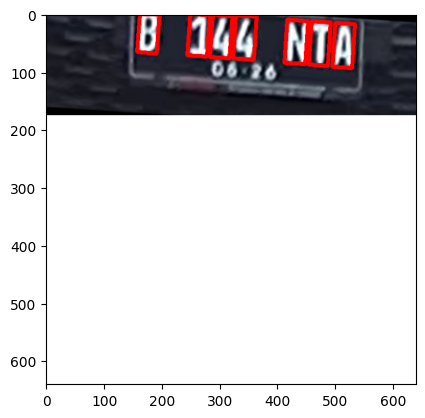

In [5]:
image, lines, confidence = next(training_image_generator)
canvas = keras_ocr.tools.drawBoxes(image=image, boxes=lines, boxes_format='lines')
plt.imshow(canvas)
plt.show()

In [9]:
detector = keras_ocr.detection.Detector()
model_dir = f'{MODEL_DIR}/keras-ocr'

batch_size = 1
training_generator, validation_generator = [
    detector.get_batch_generator(
        image_generator=image_generator, batch_size=batch_size
    ) for image_generator in
    [training_image_generator, validation_image_generator]
]
detector.model.fit_generator(
    generator=training_generator,
    steps_per_epoch=math.ceil(len(train) / batch_size),
    epochs=500,
    workers=0,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(restore_best_weights=True, patience=5),
        tf.keras.callbacks.ModelCheckpoint(filepath=os.path.join(model_dir, 'detector_finetuned_1.h5'))
    ],
    validation_data=validation_generator,
    validation_steps=math.ceil(len(validation) / batch_size)
)

Looking for ~\.keras-ocr\craft_mlt_25k.h5
Epoch 1/500
416/416 [==============================] - 111s 261ms/step - loss: 0.0048 - val_loss: 0.0038
Epoch 2/500
416/416 [==============================] - 109s 261ms/step - loss: 0.0035 - val_loss: 0.0044
Epoch 3/500
416/416 [==============================] - 110s 264ms/step - loss: 0.0026 - val_loss: 0.0037
Epoch 4/500
416/416 [==============================] - 110s 265ms/step - loss: 0.0024 - val_loss: 0.0054
Epoch 5/500
416/416 [==============================] - 116s 278ms/step - loss: 0.0022 - val_loss: 0.0047
Epoch 6/500
416/416 [==============================] - 115s 276ms/step - loss: 0.0023 - val_loss: 0.0023
Epoch 7/500
416/416 [==============================] - 113s 272ms/step - loss: 0.0019 - val_loss: 0.0059
Epoch 8/500
416/416 [==============================] - 114s 274ms/step - loss: 0.0021 - val_loss: 0.0070
Epoch 9/500
416/416 [==============================] - 108s 261ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 10/500


In [12]:
detector.model.load_weights(os.path.join(model_dir, 'detector_finetuned_1.h5'))

In [62]:
image, lines, confidence = next(validation_image_generator)
prediction_groups = detector.detect(images=[image])
prediction_groups

[array([[[110.,  52.],
         [426.,  52.],
         [426., 112.],
         [110., 112.]],
 
        [[422.,  52.],
         [506.,  52.],
         [506., 116.],
         [422., 116.]]], dtype=float32)]

In [36]:
prediction_groups[0]

array([[[128.31107 ,  13.338518],
        [508.772   ,  19.679535],
        [507.2974  , 108.15495 ],
        [126.83646 , 101.813934]]], dtype=float32)

In [19]:
lines

[[(array([[137.14285714,  17.95918367],
          [171.42857143,  17.95918367],
          [171.42857143,  97.95918367],
          [137.14285714,  97.95918367]]),
   'B'),
  (array([[225.30612245,  21.2244898 ],
          [243.26530612,  21.2244898 ],
          [243.26530612,  97.95918367],
          [225.30612245,  97.95918367]]),
   '1'),
  (array([[251.42857143,  16.32653061],
          [284.08163265,  16.32653061],
          [284.08163265,  97.95918367],
          [251.42857143,  97.95918367]]),
   '6'),
  (array([[288.97959184,  21.2244898 ],
          [323.26530612,  21.2244898 ],
          [323.26530612,  96.32653061],
          [288.97959184,  96.32653061]]),
   '8'),
  (array([[326.53061224,  21.2244898 ],
          [357.55102041,  21.2244898 ],
          [357.55102041,  97.95918367],
          [326.53061224,  97.95918367]]),
   '2'),
  (array([[390.20408163,  22.85714286],
          [424.48979592,  22.85714286],
          [424.48979592,  99.59183673],
          [390.20408163, 

In [47]:
for _, box in enumerate(prediction_groups[0][0]):
    print(box)

[128.31107   13.338518]
[508.772     19.679535]
[507.2974  108.15495]
[126.83646  101.813934]


In [49]:
canvas = keras_ocr.tools.drawBoxes(image=image, boxes=[(1, pred) for pred in prediction_groups[0][0]], boxes_format='predictions')
plt.imshow(canvas)

error: OpenCV(4.7.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\drawing.cpp:2434: error: (-215:Assertion failed) p.checkVector(2, CV_32S) >= 0 in function 'cv::polylines'


# Fine Tuning Recognizer Model

In [92]:
train_labels = keras_ocr.datasets.get_born_digital_recognizer_dataset(
    split='train',
    cache_dir='.'
)
test_labels = keras_ocr.datasets.get_born_digital_recognizer_dataset(
    split='test',
    cache_dir='.'
)
train_labels = [(filepath, box, word.lower()) for filepath, box, word in train_labels]
test_labels = [(filepath, box, word.lower()) for filepath, box, word in train_labels]

Looking for .\borndigital\Challenge1_Training_Task3_Images_GT.zip
Looking for .\borndigital\Challenge1_Test_Task3_Images.zip
Looking for .\borndigital\test\Challenge1_Test_Task3_GT.txt


In [93]:
train_labels

[('.\\borndigital\\train\\word_1.png', None, 'flying'),
 ('.\\borndigital\\train\\word_2.png', None, 'today'),
 ('.\\borndigital\\train\\word_3.png', None, 'means'),
 ('.\\borndigital\\train\\word_4.png', None, 'vueling'),
 ('.\\borndigital\\train\\word_5.png', None, 'get'),
 ('.\\borndigital\\train\\word_6.png', None, 'away,'),
 ('.\\borndigital\\train\\word_7.png', None, '1.000.000'),
 ('.\\borndigital\\train\\word_8.png', None, 'seats'),
 ('.\\borndigital\\train\\word_9.png', None, 'from'),
 ('.\\borndigital\\train\\word_10.png', None, '30€'),
 ('.\\borndigital\\train\\word_11.png', None, 'book'),
 ('.\\borndigital\\train\\word_12.png', None, 'now!'),
 ('.\\borndigital\\train\\word_13.png', None, 'smi'),
 ('.\\borndigital\\train\\word_14.png', None, 'sensomotoric'),
 ('.\\borndigital\\train\\word_15.png', None, 'instruments'),
 ('.\\borndigital\\train\\word_16.png', None, 'newsletter'),
 ('.\\borndigital\\train\\word_17.png', None, 'click'),
 ('.\\borndigital\\train\\word_18.png', N

In [94]:
train_df = pd.read_csv(f"{DATA_DIR}/DataTrain.csv", sep=";").drop(columns=['Unnamed: 0'])
train_df.Vehicleregistrationplate = train_df.Vehicleregistrationplate.str.lower()
train_df.head()

,Vehicleregistrationplate,NameofFile
0,a7814,DataTrain1.png
1,b1074qo,DataTrain2.png
2,b1031qo,DataTrain3.png
3,b187eda,DataTrain4.png
4,b1089vd,DataTrain5.png


In [95]:
images_path = f"{DATA_DIR}/train images"
train_labels = [(f"{images_path}/{filename}", None, label) for i, label, filename in train_df.itertuples()]
train_labels

[('./dataset/train images/DataTrain1.png', None, 'a7814'),
 ('./dataset/train images/DataTrain2.png', None, 'b1074qo'),
 ('./dataset/train images/DataTrain3.png', None, 'b1031qo'),
 ('./dataset/train images/DataTrain4.png', None, 'b187eda'),
 ('./dataset/train images/DataTrain5.png', None, 'b1089vd'),
 ('./dataset/train images/DataTrain6.png', None, 'b1972rbp'),
 ('./dataset/train images/DataTrain7.png', None, 'ab2400wu'),
 ('./dataset/train images/DataTrain8.png', None, 'ab6268yq'),
 ('./dataset/train images/DataTrain9.png', None, 'a8014va'),
 ('./dataset/train images/DataTrain10.png', None, 'b1554eja'),
 ('./dataset/train images/DataTrain11.png', None, 'b1160bh'),
 ('./dataset/train images/DataTrain12.png', None, 'b1032pje'),
 ('./dataset/train images/DataTrain13.png', None, 'b173put'),
 ('./dataset/train images/DataTrain14.png', None, 'b111hsn'),
 ('./dataset/train images/DataTrain15.png', None, 'b1254tfx'),
 ('./dataset/train images/DataTrain16.png', None, 'b1618wyj'),
 ('./dataset

In [85]:
recognizer = keras_ocr.recognition.Recognizer()
recognizer.compile()

Looking for ~\.keras-ocr\crnn_kurapan.h5


In [96]:
batch_size = 8
augmenter = imgaug.augmenters.Sequential([
    imgaug.augmenters.GammaContrast(gamma=(0.25, 3.0)),
])

train_labels, validation_labels = train_test_split(train_labels, test_size=0.2, random_state=42)
(training_image_gen, training_steps), (validation_image_gen, validation_steps) = [
    (
        keras_ocr.datasets.get_recognizer_image_generator(
            labels=labels,
            height=recognizer.model.input_shape[1],
            width=recognizer.model.input_shape[2],
            alphabet=recognizer.alphabet,
            augmenter=augmenter
        ),
        len(labels) // batch_size
    ) for labels, augmenter in [(train_labels, augmenter), (validation_labels, None)]
]
training_gen, validation_gen = [
    recognizer.get_batch_generator(
        image_generator=image_generator,
        batch_size=batch_size
    )
    for image_generator in [training_image_gen, validation_image_gen]
]

text: b1817ul


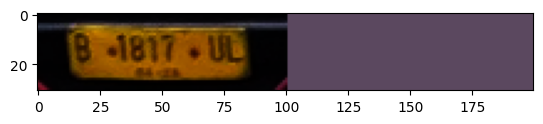

In [90]:
image, text = next(training_image_gen)
print('text:', text)
_ = plt.imshow(image)

In [97]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, restore_best_weights=False),
    tf.keras.callbacks.ModelCheckpoint(f'{model_dir}/recognizer_finetuned_1.h5', monitor='val_loss', save_best_only=True),
    tf.keras.callbacks.CSVLogger(f'{model_dir}/recognizer_finetuned_1.csv')
]
recognizer.training_model.fit_generator(
    generator=training_gen,
    steps_per_epoch=training_steps,
    validation_steps=validation_steps,
    validation_data=validation_gen,
    callbacks=callbacks,
    epochs=500,
)

Epoch 1/500
80/80 [==============================] - 374s 2s/step - loss: 15.3239 - val_loss: 13.0481
Epoch 2/500
80/80 [==============================] - 145s 2s/step - loss: 8.4856 - val_loss: 11.3628
Epoch 3/500
80/80 [==============================] - 148s 2s/step - loss: 6.2104 - val_loss: 9.9488
Epoch 4/500
80/80 [==============================] - 143s 2s/step - loss: 4.8745 - val_loss: 9.7298
Epoch 5/500
80/80 [==============================] - 146s 2s/step - loss: 4.0080 - val_loss: 8.2078
Epoch 6/500
80/80 [==============================] - 149s 2s/step - loss: 2.9246 - val_loss: 8.8360
Epoch 7/500
80/80 [==============================] - 168s 2s/step - loss: 2.7815 - val_loss: 7.6476
Epoch 8/500
80/80 [==============================] - 148s 2s/step - loss: 2.2818 - val_loss: 7.2261
Epoch 9/500
80/80 [==============================] - 154s 2s/step - loss: 2.0734 - val_loss: 8.4921
Epoch 10/500
80/80 [==============================] - 157s 2s/step - loss: 1.7782 - val_loss: 6.3

In [99]:
recognizer.training_model.load_weights(f'{model_dir}/recognizer_finetuned_1.h5')

Predicted: aotose, Actual: ad7034oe


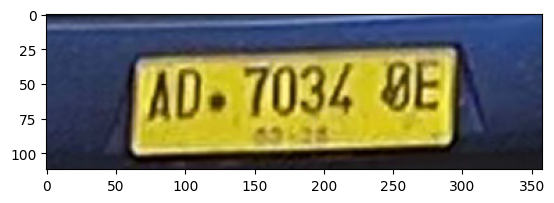

In [108]:
predicted = recognizer.recognize(f"{DATA_DIR}/test images/DataTest1.png")
print(f'Predicted: {predicted}, Actual: ad7034oe')
_ = plt.imshow(keras_ocr.tools.read(f"{DATA_DIR}/test images/DataTest1.png"))

## Before Fine Tuning

Predicted: baboun


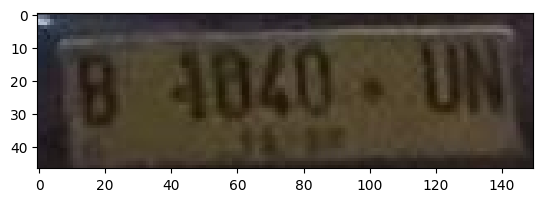

Predicted: gsker


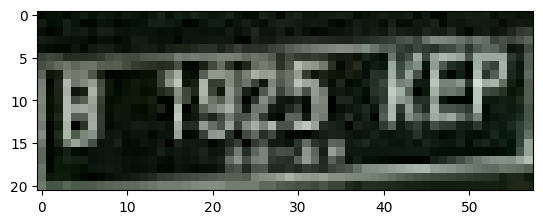

Predicted: scatiztly


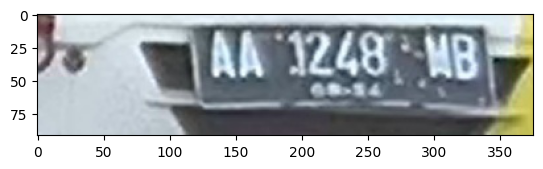

Predicted: bigioz


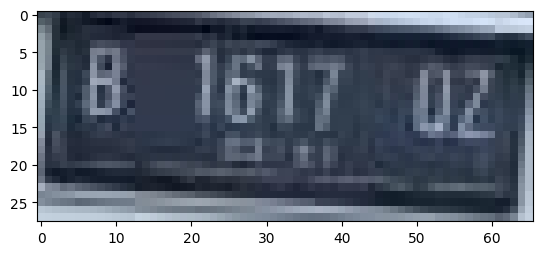

Predicted: biste


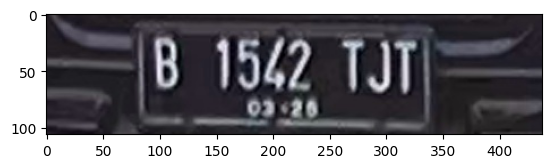

Predicted: bbssn


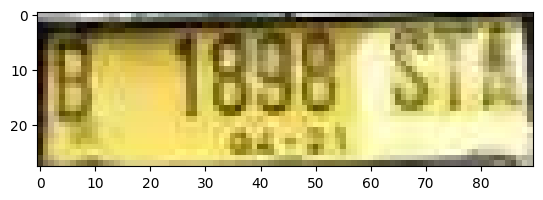

Predicted: sosaue


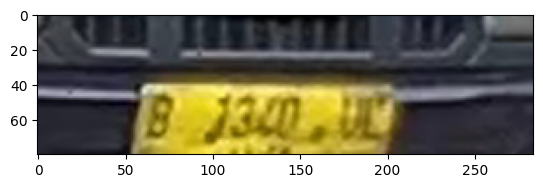

Predicted: busey


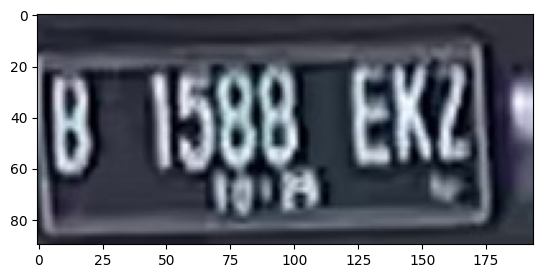

Predicted: brabisoul


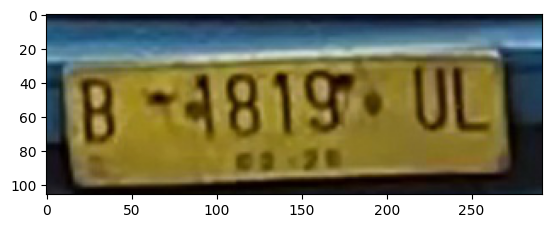

Predicted: baznt


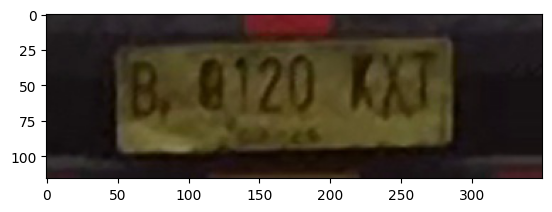

Predicted: biose


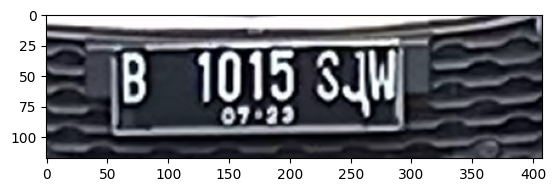

Predicted: sbnoize


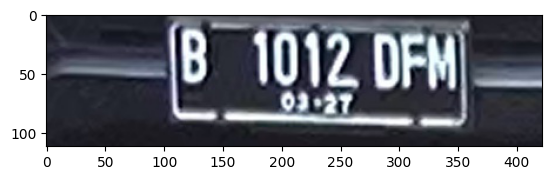

Predicted: bizsird


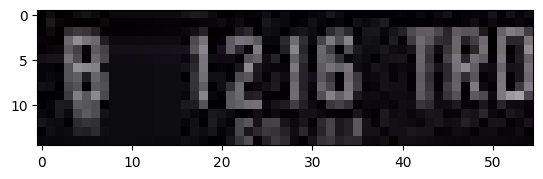

Predicted: biss


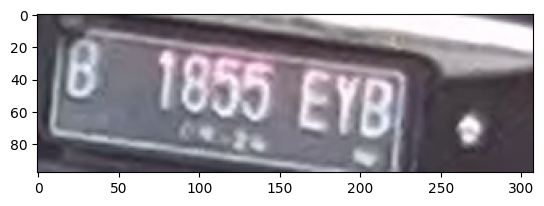

Predicted: bsepi


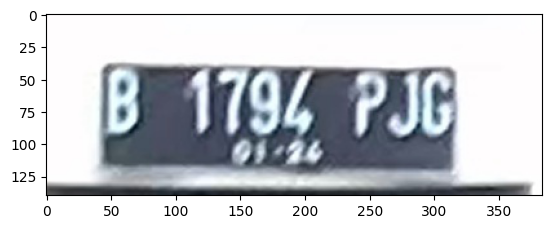

Predicted: abibbre


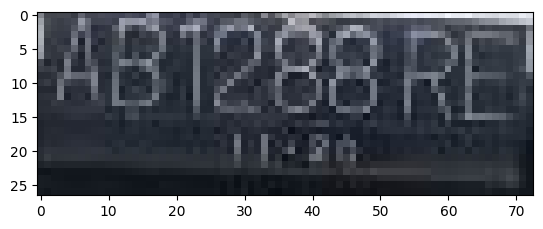

Predicted: sbiztowes


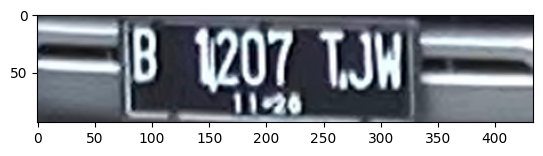

Predicted: sbisbib


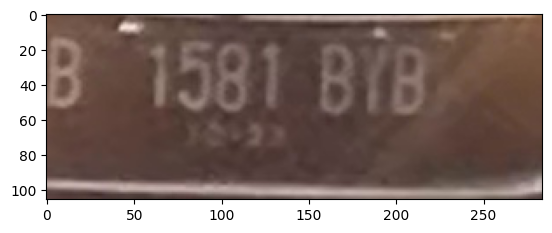

Predicted: biesiorfs


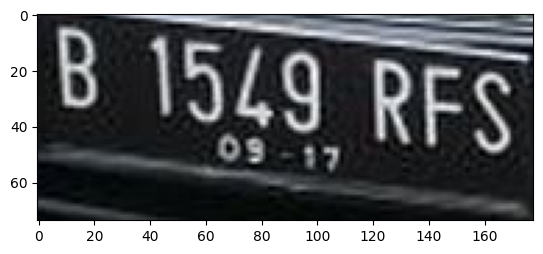

Predicted: mozton


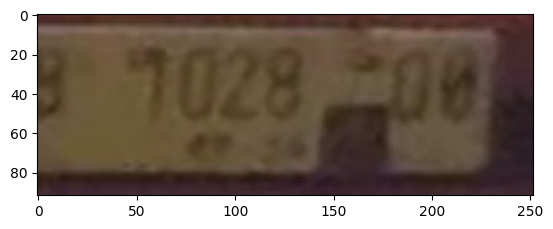

In [114]:
for path in sorted(glob.glob(f'{DATA_DIR}/train images - Copy/*.png'), key=lambda x: int(x.split("\\")[-1].split(".")[0][9:]))[:20]:
    predicted = recognizer.recognize(path)
    print(f'Predicted: {predicted}')
    _ = plt.imshow(keras_ocr.tools.read(path))
    plt.show()

## After Fine Tuning

Predicted: b1040un


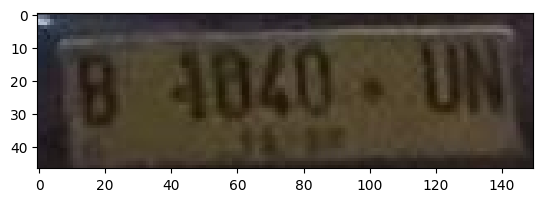

Predicted: b1925kep


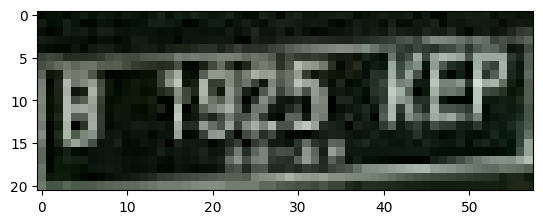

Predicted: aa1248mb


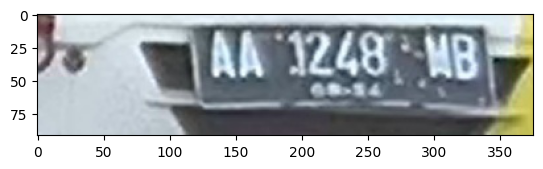

Predicted: b1617qz


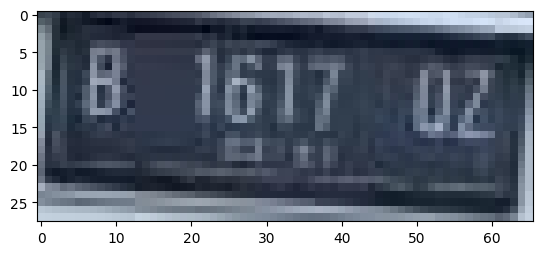

Predicted: b1542tjt


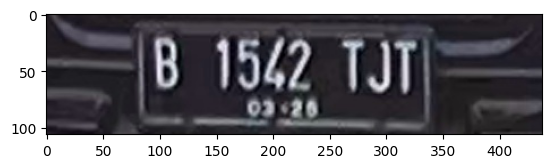

Predicted: b1898sta


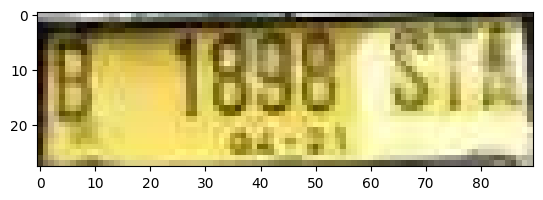

Predicted: b1310uvi


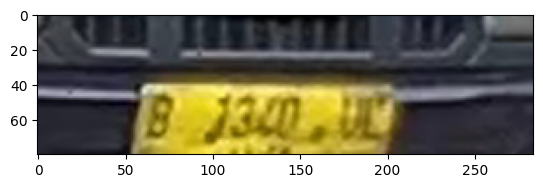

Predicted: b1588ekz


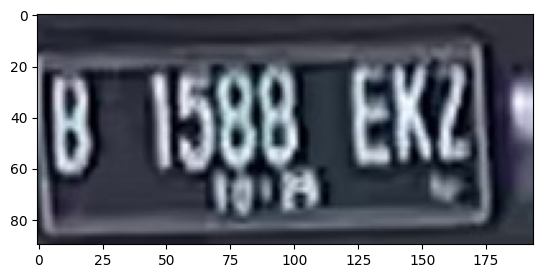

Predicted: b1819ul


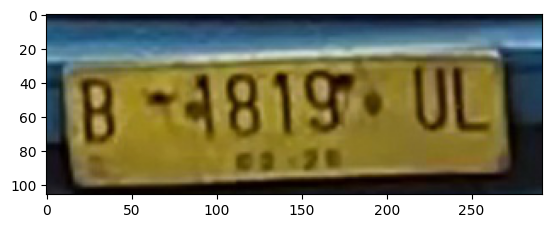

Predicted: b0120kxt


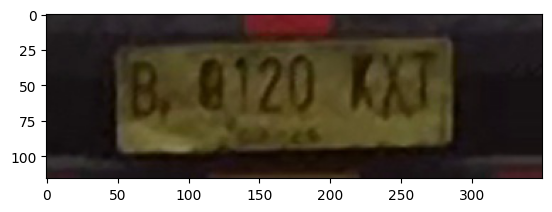

Predicted: b1015sjw


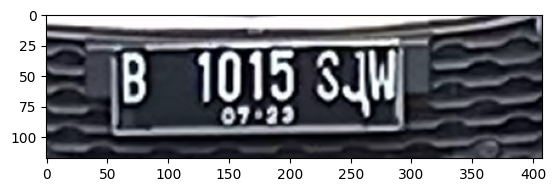

Predicted: b1012dfm


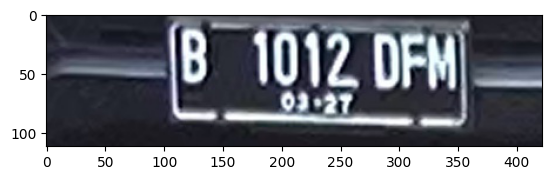

Predicted: b1216trd


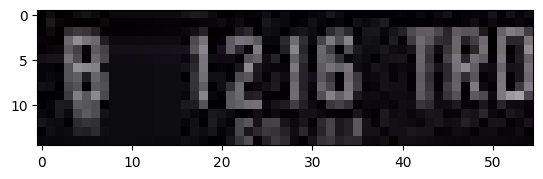

Predicted: b1855eyb


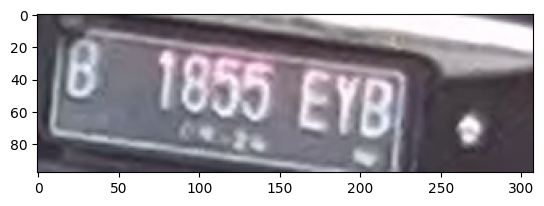

Predicted: b1794pjg


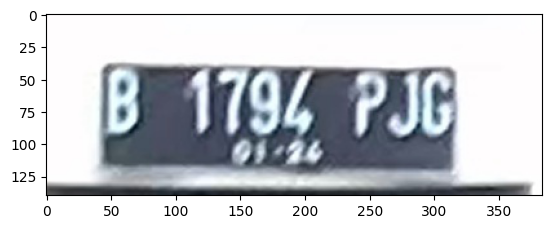

Predicted: ab1288re


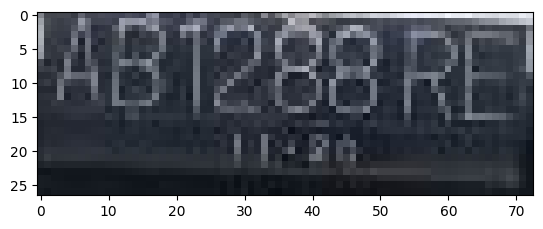

Predicted: b1207tjw


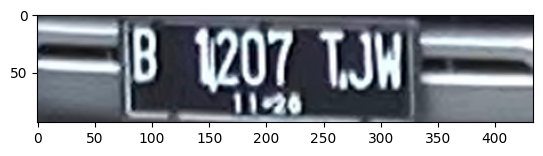

Predicted: b15818b


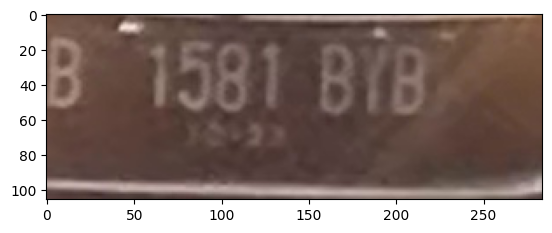

Predicted: b1549rfs


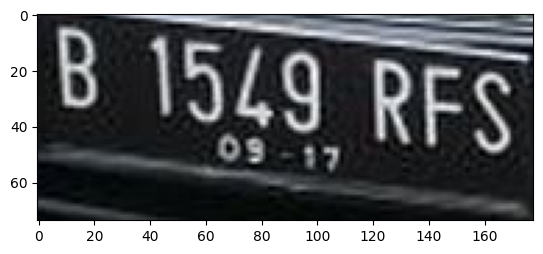

Predicted: b1028qo


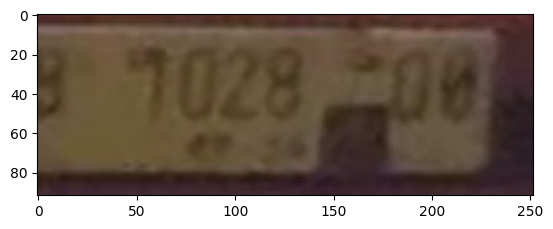

In [112]:
for path in sorted(glob.glob(f'{DATA_DIR}/train images - Copy/*.png'), key=lambda x: int(x.split("\\")[-1].split(".")[0][9:]))[:20]:
    predicted = recognizer.recognize(path)
    print(f'Predicted: {predicted}')
    _ = plt.imshow(keras_ocr.tools.read(path))
    plt.show()

In [115]:
recognizer = keras_ocr.recognition.Recognizer()
recognizer_ft = keras_ocr.recognition.Recognizer()
recognizer_ft.model.load_weights(f"{MODEL_DIR}/keras-ocr/recognizer_finetuned_1.h5")

Looking for ~\.keras-ocr\craft_mlt_25k.h5
Looking for ~\.keras-ocr\crnn_kurapan.h5
Looking for ~\.keras-ocr\crnn_kurapan.h5


In [121]:
test_df = pd.read_csv(f"{DATA_DIR}/data_test_labeled.csv", index_col=0)
test_df.label = test_df.label.str.lower()
test_df.head()

,Name of File,label
0,DataTest1.png,ad7034oe
1,DataTest2.png,a9388ex
2,DataTest3.png,b16tb
3,DataTest4.png,b1661tkz
4,DataTest5.png,ad3772abe


### Before Fine Tuning

In [126]:
for i, filename, label in test_df.itertuples():
    path = f"{DATA_DIR}/test images/{filename}"
    predicted = recognizer.recognize(path)
    print(f'Predicted: {predicted}, Actual: {label}')
    test_df.loc[i, 'predicted'] = predicted

Predicted: aotose, Actual: ad7034oe
Predicted: sae, Actual: a9388ex
Predicted: babitb, Actual: b16tb
Predicted: biggikze, Actual: b1661tkz
Predicted: psizng, Actual: ad3772abe
Predicted: bee, Actual: b2271hv
Predicted: biogalter, Actual: b1064tfr
Predicted: begtms, Actual: b1395tjw
Predicted: sniziord, Actual: b1270rfd
Predicted: bnibey, Actual: b1738byh
Predicted: gtse, Actual: b1627bie
Predicted: blisa, Actual: b1678wzm
Predicted: naogness, Actual: ad9313ss
Predicted: snoe, Actual: b1036ul
Predicted: pioatns, Actual: b1801tzs
Predicted: altits, Actual: b1474tjs
Predicted: clsao, Actual: b1939pu
Predicted: bizoizt, Actual: b1260tzt
Predicted: ibsintie, Actual: b1376tjo
Predicted: e, Actual: b1qo
Predicted: abimlas, Actual: ab8328iz
Predicted: balbpn, Actual: b1236pzn
Predicted: sbegle, Actual: ab8644pk
Predicted: botkt, Actual: b1jkt
Predicted: mntoa, Actual: aa7084od
Predicted: putten, Actual: b1131ekg
Predicted: srtare, Actual: b1037un
Predicted: biogele, Actual: b1036ul
Predicted: 

### After Fine Tuning

In [132]:
for i, filename, label, _ in test_df.itertuples():
    path = f"{DATA_DIR}/test images/{filename}"
    predicted = recognizer_ft.recognize(path)
    print(f'Predicted: {predicted}, Actual: {label}')
    test_df.loc[i, 'predicted_ft'] = predicted

Predicted: ad0704o, Actual: ad7034oe
Predicted: a9388e, Actual: a9388ex
Predicted: b161tpb, Actual: b16tb
Predicted: b1661tkz, Actual: b1661tkz
Predicted: ab429v, Actual: ad3772abe
Predicted: b173quv, Actual: b2271hv
Predicted: b1064tfr, Actual: b1064tfr
Predicted: b1395tjw, Actual: b1395tjw
Predicted: b1270rfd, Actual: b1270rfd
Predicted: b1736bym, Actual: b1738byh
Predicted: b18427pbie, Actual: b1627bie
Predicted: b168za, Actual: b1678wzm
Predicted: ad313ss, Actual: ad9313ss
Predicted: b1036ul, Actual: b1036ul
Predicted: b1801tzs, Actual: b1801tzs
Predicted: b1474tjs, Actual: b1474tjs
Predicted: b139pu, Actual: b1939pu
Predicted: b1260izt, Actual: b1260tzt
Predicted: b1376tjo, Actual: b1376tjo
Predicted: b17qo, Actual: b1qo
Predicted: ab862kh, Actual: ab8328iz
Predicted: b1236pzm, Actual: b1236pzn
Predicted: ab8644pk, Actual: ab8644pk
Predicted: b1jki, Actual: b1jkt
Predicted: aa70540, Actual: aa7084od
Predicted: b131ekg, Actual: b1131ekg
Predicted: b103n, Actual: b1037un
Predicted: 

## Prediction Results

In [133]:
test_df

,Name of File,label,predicted,predicted_ft
0,DataTest1.png,ad7034oe,aotose,ad0704o
1,DataTest2.png,a9388ex,sae,a9388e
2,DataTest3.png,b16tb,babitb,b161tpb
3,DataTest4.png,b1661tkz,biggikze,b1661tkz
4,DataTest5.png,ad3772abe,psizng,ab429v
...,...,...,...,...
95,DataTest96.png,b1285ul,basrn,b435s
96,DataTest97.png,ab8644pk,sablg,ab864pk
97,DataTest98.png,ag9718eg,aggzibteg,ag9718egc
98,DataTest99.png,b1509un,biune,b1509un


### Evaluation

In [137]:
for i, cols in test_df.iterrows():
    correct_char = 0
    for j in range(min(len(cols.label), len(cols.predicted_ft))):
        if cols.label[j] == cols.predicted_ft[j]:
            correct_char += 1
    test_df.loc[i, 'accuracy'] = correct_char / len(cols.label)

test_df

,Name of File,label,predicted,predicted_ft,accuracy
0,DataTest1.png,ad7034oe,aotose,ad0704o,0.500000
1,DataTest2.png,a9388ex,sae,a9388e,0.857143
2,DataTest3.png,b16tb,babitb,b161tpb,0.600000
3,DataTest4.png,b1661tkz,biggikze,b1661tkz,1.000000
4,DataTest5.png,ad3772abe,psizng,ab429v,0.111111
...,...,...,...,...,...
95,DataTest96.png,b1285ul,basrn,b435s,0.142857
96,DataTest97.png,ab8644pk,sablg,ab864pk,0.625000
97,DataTest98.png,ag9718eg,aggzibteg,ag9718egc,1.000000
98,DataTest99.png,b1509un,biune,b1509un,1.000000


In [138]:
test_df.accuracy.mean()

0.7145158730158729